In [3]:
import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import torch
from collections import Counter
from scipy import stats


In [4]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]

    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]

    return df_data, republican_df, democratic_df

In [5]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])

In [6]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politcian
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [7]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [8]:
def merge_communities_by_edge_count(G, communities):
    """Merge a list of communities into exactly two based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.

    Returns:
        list of set: Two communities merged based on edge connectivity.
    """
    if len(communities) < 2:
        raise ValueError("There must be at least two communities to merge into two.")
    
    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]
    
    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)
    
    # Start with the two largest communities
    large_community_one, large_community_two = communities[:2]
    
    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into one of these two
    for community in communities[2:]:
        edges_to_one = count_edges_between(community, large_community_one)
        edges_to_two = count_edges_between(community, large_community_two)
        
        if edges_to_one > edges_to_two:
            large_community_one.update(community)
        else:
            large_community_two.update(community)

    return [large_community_one, large_community_two]

In [9]:
from networkx.algorithms.community import greedy_modularity_communities, modularity

def apply_greedy_modularity_two_partitions(G):
    """Applies greedy modularity community detection and merges results into two communities.

    Args:
        G (networkx.Graph): The graph on which to apply the community detection.

    Returns:
        tuple: Contains the two communities, party alignment, modularity of the partition, and community labels.
    """
    # Detect communities using greedy modularity maximization
    initial_communities = greedy_modularity_communities(G)
    # print(len(initial_communities))

    # Merge communities into two
    if len(initial_communities) > 2:
        communities = merge_communities_by_edge_count(G, initial_communities)
        # communities = merge_communities_max_modularity(G, initial_communities)
        # communities = merge_into_two_communities(initial_communities)
    else:
        communities = [set(community) for community in initial_communities]

    # Analyze alignment with political parties
    alignment = {1: {'R': 0, 'D': 0}, 2: {'R': 0, 'D': 0}}
    for idx, community in enumerate(communities):
        for node in community:
            party = G.nodes[node]['party']
            alignment[idx + 1][party] += 1

    # Calculate modularity for the two communities
    mod_value = modularity(G, communities)
    # print(f"Modularity of the partition: {mod_value}")

    # Classify communities based on dominant party
    comm_labels = classify_communities(alignment)

    return communities, alignment, mod_value, comm_labels


In [10]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [11]:
def apply_greedy_modularity_n_partitions(G, no_of_communities):
    """Applies greedy modularity community detection and merges results into two communities.

    Args:
        G (networkx.Graph): The graph on which to apply the community detection.

    Returns:
        tuple: Contains the two communities, party alignment, modularity of the partition, and community labels.
    """
    # Detect communities using greedy modularity maximization
    initial_communities = greedy_modularity_communities(G)

    # Merge communities into two
    if len(initial_communities) > no_of_communities:
        communities = merge_n_communities_by_edge_count(G, initial_communities, no_of_communities)
        # communities = merge_communities_into_two_by_edge_count(G, initial_communities)
        # communities = merge_communities_max_modularity(G, initial_communities)
        # communities = merge_into_two_communities(initial_communities)
    else:
        communities = [set(community) for community in initial_communities]

    # Calculate modularity for the two communities
    mod_value = modularity(G, communities)
    # print(f"Modularity of the partition: {mod_value}")

    return communities, mod_value#alignment, mod_value, comm_labels


In [12]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [13]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [14]:
def calc_hits_values(G, df_data):
    # Compute HITS scores
    hub_scores, authority_scores = nx.hits(G, max_iter=100, tol=1e-7)
    
    # Store the HITS scores as node attributes
    for node in G.nodes():
        if node not in df_data['current_twitter_name'].values:
            G.nodes[node]['hub_score'] = hub_scores.get(node, 0)
            G.nodes[node]['authority_score'] = authority_scores.get(node, 0)
        else:
            authority_scores.pop(node)
            hub_scores.pop(node)
    
    # returning below to easily calc percentiles etc
    return authority_scores, hub_scores

In [15]:
def calc_centrality_values(G, df_data):
    
    """ Betweenness Centrality: How often a node acts as a bridge along the shortest path between two other nodes - high means node has considerable influence over spread of info through the network
        Closeness Centrality: Measures how close a node is to all other node in the network, based on shortest path - high means node can interact quickly with others in the network
        YES = Eigenvector Centrality: Measures connection quality - connection to high scoring nodes contribute more to the score than low scoring nodes
        YES = Degree Centrality: Measures the number of direct connections to other nodes - high means more connections """
    
    degree_centrality = nx.degree_centrality(G)
    # Store the scores as node attributes
    for node in G.nodes():
        # if node not in df_data['current_twitter_name'].values:
        G.nodes[node]['degree'] = degree_centrality.get(node, 0)
        # else:
        #     degree_centrality.pop(node)

    return degree_centrality

In [16]:
def add_important_following_column(G, df_data, auth_thresh):

    """ Use calculated HITS values to add new column of the following if 
    they are above the authority value threshold """

    # Create a set of nodes to retain
    retained_nodes = set()
    for node in G.nodes:
        if G.nodes[node]['authority_score'] >= auth_thresh or (
            node in df_data['current_twitter_name'].values):
            retained_nodes.add(node)

    # Create a new column 'important_following'
    important_following = []
    for _, row in df_data.iterrows():
        following_list = row['following']
        
        # Filter the followings to retain only those in the retained_nodes set
        filtered_following = [f for f in following_list if f in retained_nodes]
        important_following.append(filtered_following)

    # Add the new column to the dataframe
    df_data['important_following'] = important_following
    return df_data

In [17]:
df_data, republican_df, democratic_df = read_data(-1)
G_bipartite = build_bipartite_network(df_data)
degree_lower_2_remover(df_data, G_bipartite)
# df_data


In [18]:
print("Number of nodes:", G_bipartite.number_of_nodes())
print("Number of edges:", G_bipartite.number_of_edges())

Number of nodes: 164122
Number of edges: 306363


In [19]:
G_bipartite = build_bipartite_network(df_data)
print("Number of nodes:", G_bipartite.number_of_nodes())
print("Number of edges:", G_bipartite.number_of_edges())

Number of nodes: 34364
Number of edges: 176605


In [18]:
auth_dict, hub_dict = calc_hits_values(G_bipartite, df_data)
# degree_dict = calc_centrality_values(G_bipartite, df_data)

**CHECKING ONLY POLITICIANS DEGREE AND AUTHORITY SCORES**

164
Sample degrees: [226, 447, 1571, 740, 4528, 2168, 151, 1199, 561, 1706]
Degree count sample: {226: 1, 447: 1, 1571: 1, 740: 1, 4528: 1, 2168: 1, 151: 1, 1199: 1, 561: 1, 1706: 1}


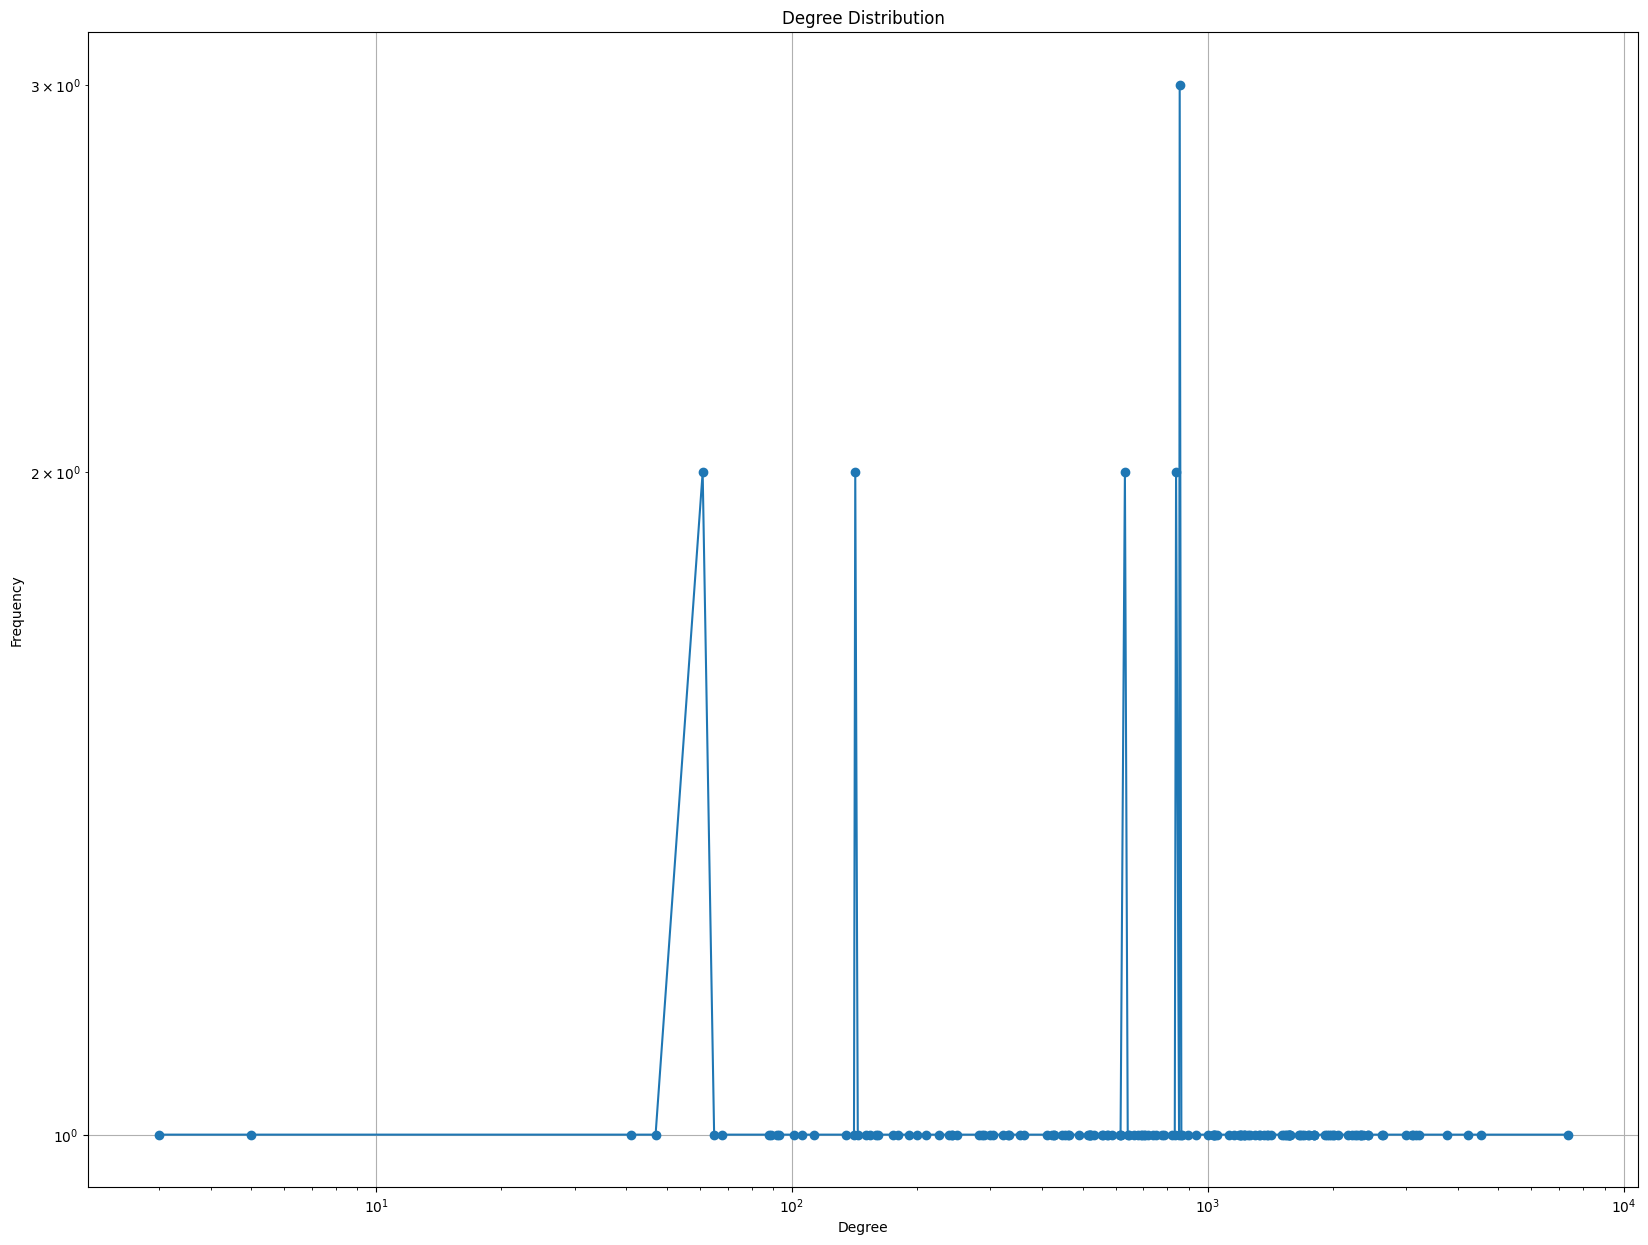

Mean Degree: 1076.8597560975609
Median Degree: 803.5
Mode Degree: 856
Minimum Degree: 3
Maximum Degree: 7340
Standard Deviation: 1012.6971044955145
25th Percentile: 331.5
50th Percentile: 803.5
75th Percentile: 1565.5


In [19]:
# Calculating degrees
degree_dict = {node: G_bipartite.degree(node) for node in G_bipartite.nodes() if node in df_data['current_twitter_name'].values}
degrees = list(degree_dict.values())
print(len(degrees))
# Check first few entries to ensure they are calculated
print("Sample degrees:", degrees[:10])

# Counting degrees
degree_count = Counter(degrees)

# Display the counts of the first few degrees to understand the distribution
print("Degree count sample:", dict(list(degree_count.items())[:10]))

# Sorting keys for plotting
sorted_degrees = sorted(degree_count.keys())
sorted_counts = [degree_count[degree] for degree in sorted_degrees]

plt.figure(figsize=(20, 15))
plt.plot(sorted_degrees, sorted_counts, marker='o', linestyle='-')
plt.yscale('log')  # Apply logarithmic scale on the y-axis
plt.xscale('log')  # Apply logarithmic scale on the x-axis if needed
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

degrees_array = np.array(degrees)

# Calculate basic statistics
mean_degree = np.mean(degrees_array)
median_degree = np.median(degrees_array)
mode_degree = stats.mode(degrees_array, keepdims=True)[0][0]  # The mode function returns mode and count
min_degree = np.min(degrees_array)
max_degree = np.max(degrees_array)
std_degree = np.std(degrees_array)

# Calculate percentiles
percentile_25 = np.percentile(degrees_array, 25)
percentile_50 = np.percentile(degrees_array, 50)  # Same as median
percentile_75 = np.percentile(degrees_array, 75)

# Print the results
print(f"Mean Degree: {mean_degree}")
print(f"Median Degree: {median_degree}")
print(f"Mode Degree: {mode_degree}")
print(f"Minimum Degree: {min_degree}")
print(f"Maximum Degree: {max_degree}")
print(f"Standard Deviation: {std_degree}")
print(f"25th Percentile: {percentile_25}")
print(f"50th Percentile: {percentile_50}")
print(f"75th Percentile: {percentile_75}")

In [20]:
# # Assuming authority_scores_dict is your dictionary with authority scores
# # authority_scores = list(auth_dict.values())
# filtered_auth_dict = {node: auth_dict[node] for node in auth_dict if node in df_data['current_twitter_name'].values}
# authority_scores = list(filtered_auth_dict.values())

# print(len(authority_scores))

# # Calculate the frequency of each authority score
# authority_score_count = Counter(authority_scores)

# # Sort the scores and their frequencies for plotting
# sorted_scores = sorted(authority_score_count.keys())
# sorted_frequencies = [authority_score_count[score] for score in sorted_scores]
# print(authority_score_count)
# plt.figure(figsize=(20, 15))
# plt.plot(sorted_scores, sorted_frequencies, marker='o', linestyle='-', color='blue')
# # plt.yscale('log')  # Apply logarithmic scale on the y-axis if the range of frequencies is large
# plt.xscale('log')
# plt.title("Authority Score Distribution")
# plt.xlabel("Authority Score")
# plt.ylabel("Frequency")
# plt.grid(True)
# plt.show()

# """ BEST VALUE SEEMS TO BE 6.792489709315934e-07 TO REMOVE BELOW """


# auth_array = np.array(authority_scores)

# # Calculate basic statistics
# mean_degree = np.mean(auth_array)
# median_degree = np.median(auth_array)
# mode_degree = stats.mode(auth_array, keepdims=True)[0][0]  # The mode function returns mode and count
# min_degree = np.min(auth_array)
# max_degree = np.max(auth_array)
# std_degree = np.std(auth_array)

# # Calculate percentiles
# percentile_25 = np.percentile(auth_array, 25)
# percentile_50 = np.percentile(auth_array, 50)  # Same as median
# percentile_75 = np.percentile(auth_array, 75)

# # Print the results
# print(f"Mean Degree: {mean_degree}")
# print(f"Median Degree: {median_degree}")
# print(f"Mode Degree: {mode_degree}")
# print(f"Minimum Degree: {min_degree}")
# print(f"Maximum Degree: {max_degree}")
# print(f"Standard Deviation: {std_degree}")
# print(f"25th Percentile: {percentile_25}")
# print(f"50th Percentile: {percentile_50}")
# print(f"75th Percentile: {percentile_75}")


In [21]:
# degrees = []
# authority_scores = []

# # Assuming auth_dict and degree_dict have the same keys
# for node in filtered_auth_dict:
#     degrees.append(degree_dict[node])
#     authority_scores.append(filtered_auth_dict[node])

# plt.figure(figsize=(10, 6))
# plt.scatter(degrees, authority_scores, alpha=0.6, edgecolors='w', color='blue')
# # plt.yscale('log')
# # plt.xscale('log')
# plt.title("Plot of Degree vs. Authority Scores")
# plt.xlabel("Degree")
# plt.ylabel("Authority Score")
# plt.grid(True)
# plt.show()


**ALL WEBSITES**

34200
Sample degrees: [74, 63, 63, 9, 30, 3, 40, 37, 70, 58]
Degree count sample: {74: 8, 63: 11, 9: 419, 30: 44, 3: 5853, 40: 34, 37: 28, 70: 5, 58: 14, 18: 107}


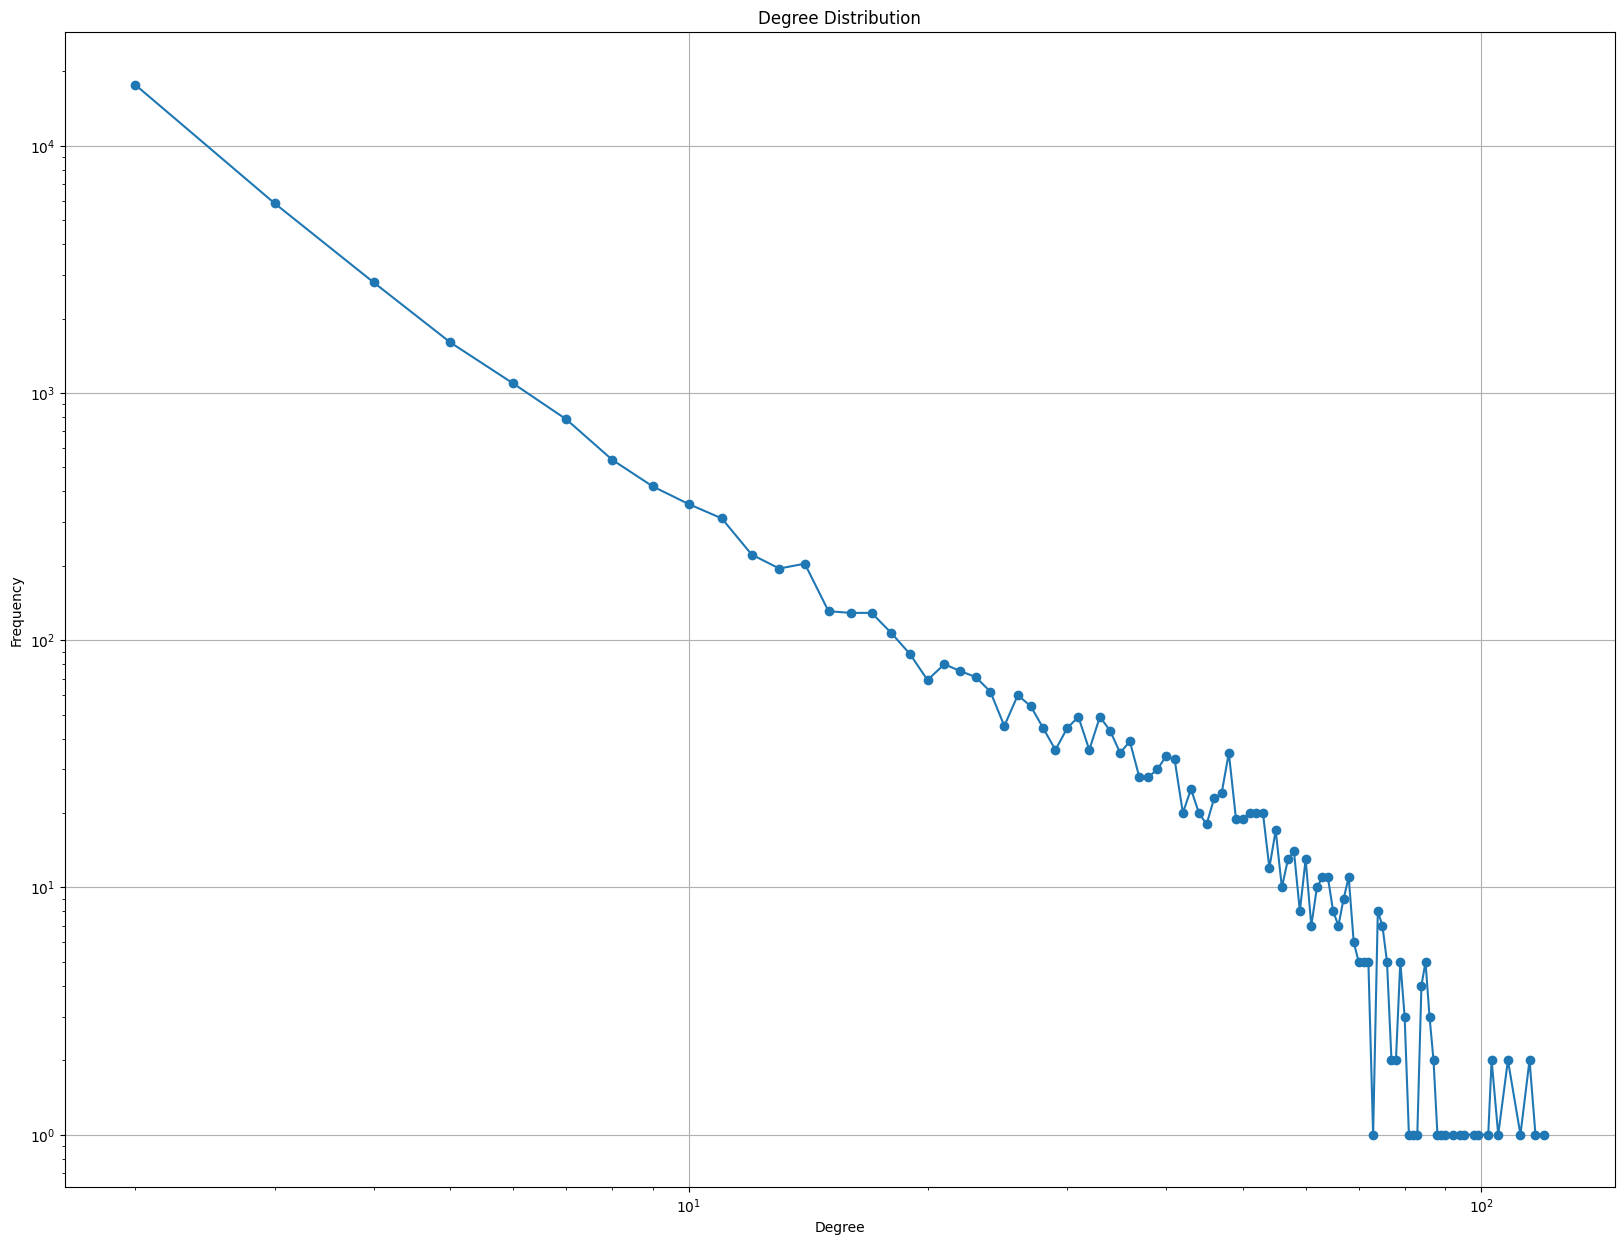

Mean Degree: 5.163888888888889
Median Degree: 2.0
Mode Degree: 2
Maximum Degree: 120
Standard Deviation: 8.535249241433158
25th Percentile: 2.0
50th Percentile: 2.0
75th Percentile: 4.0


In [22]:
# Calculating degrees
degree_dict = {node: G_bipartite.degree(node) for node in G_bipartite.nodes() if node not in df_data['current_twitter_name'].values}
degrees = list(degree_dict.values())
print(len(degrees))
# Check first few entries to ensure they are calculated
print("Sample degrees:", degrees[:10])

# Counting degrees
degree_count = Counter(degrees)

# Display the counts of the first few degrees to understand the distribution
print("Degree count sample:", dict(list(degree_count.items())[:10]))

# Sorting keys for plotting
sorted_degrees = sorted(degree_count.keys())
sorted_counts = [degree_count[degree] for degree in sorted_degrees]

plt.figure(figsize=(20, 15))
plt.plot(sorted_degrees, sorted_counts, marker='o', linestyle='-')
plt.yscale('log')  # Apply logarithmic scale on the y-axis
plt.xscale('log')  # Apply logarithmic scale on the x-axis if needed
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

degrees_array = np.array(degrees)

# Calculate basic statistics
mean_degree = np.mean(degrees_array)
median_degree = np.median(degrees_array)
mode_degree = stats.mode(degrees_array, keepdims=True)[0][0]  # The mode function returns mode and count
max_degree = np.max(degrees_array)
std_degree = np.std(degrees_array)

# Calculate percentiles
percentile_25 = np.percentile(degrees_array, 25)
percentile_50 = np.percentile(degrees_array, 50)  # Same as median
percentile_75 = np.percentile(degrees_array, 75)

# Print the results
print(f"Mean Degree: {mean_degree}")
print(f"Median Degree: {median_degree}")
print(f"Mode Degree: {mode_degree}")
print(f"Maximum Degree: {max_degree}")
print(f"Standard Deviation: {std_degree}")
print(f"25th Percentile: {percentile_25}")
print(f"50th Percentile: {percentile_50}")
print(f"75th Percentile: {percentile_75}")


34200
Counter({2.04479836683607e-05: 614, 1.157329156357448e-05: 498, 3.4222042239196866e-06: 374, 6.531197078001649e-06: 211, 9.953730754474016e-06: 175, 1.8040752296311387e-05: 163, 1.6756706827349868e-05: 160, 1.1254538370896284e-05: 123, 7.394524479644994e-06: 117, 1.1149169390544873e-05: 117, 2.0346124699181138e-05: 116, 9.635862931488327e-06: 110, 2.0642825881195053e-05: 107, 7.722284649065012e-06: 99, 3.3450375892509607e-06: 98, 1.407333528813608e-05: 96, 1.1972338239890979e-05: 91, 3.207391628987753e-05: 88, 1.2756979644074654e-05: 88, 5.12405054279364e-06: 86, 7.5896442084448875e-06: 85, 2.2975485372233036e-05: 82, 1.0054946018582073e-05: 80, 1.292772287584443e-05: 78, 2.350124133156997e-05: 76, 1.2989554258440807e-05: 76, 1.482876149319371e-05: 75, 1.708086328456785e-05: 74, 1.9316993286364898e-05: 73, 6.108530866076651e-06: 72, 8.592775336497679e-06: 72, 6.360444251279994e-06: 71, 1.430258049769119e-05: 70, 1.0079700549440259e-05: 68, 9.80738918430182e-06: 67, 9.536296017622

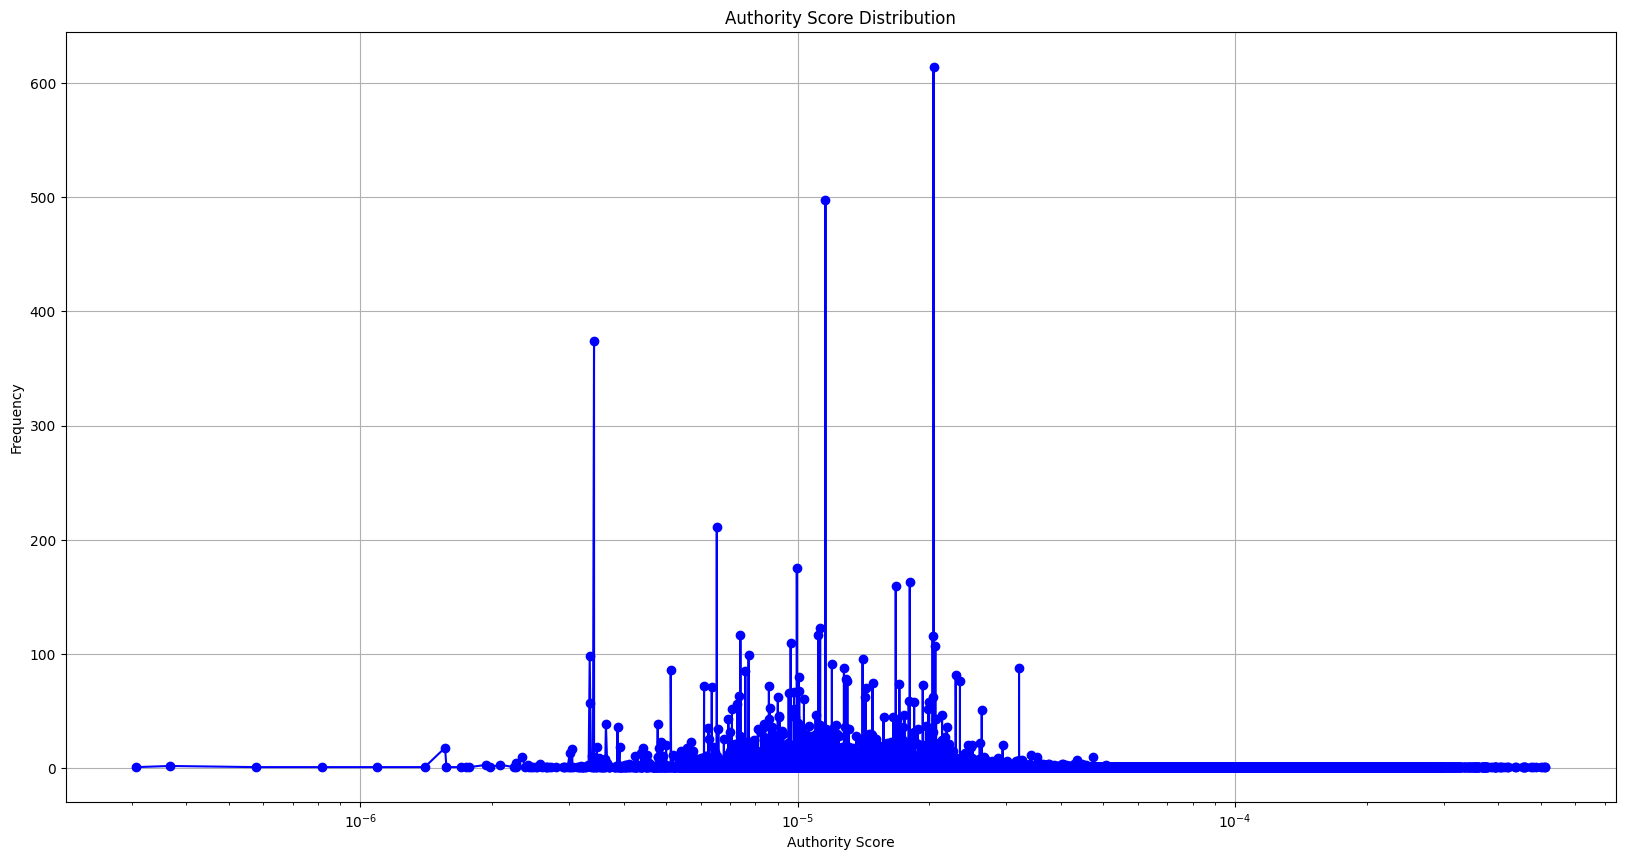

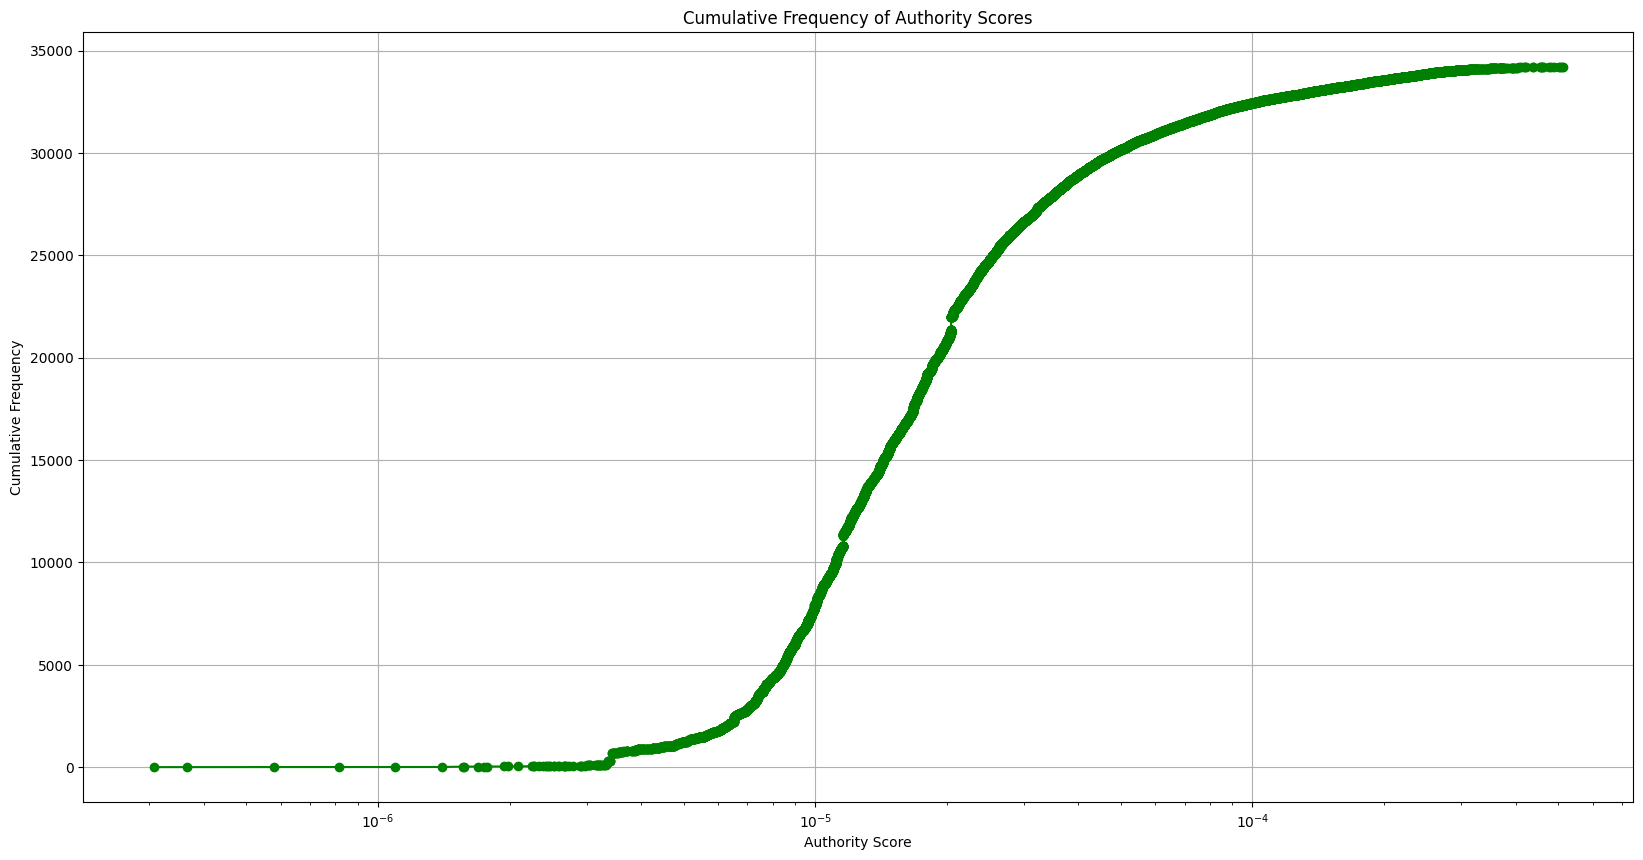

Mean Degree: 2.9239766081871346e-05
Median Degree: 1.6453581131231583e-05
Mode Degree: 2.04479836683607e-05
Maximum Degree: 0.0005120787518938562
Standard Deviation: 4.352307399305788e-05
25th Percentile: 1.0282799006972313e-05
50th Percentile: 1.6453581131231583e-05
75th Percentile: 2.6920500162252462e-05


In [23]:
# Assuming authority_scores_dict is your dictionary with authority scores
authority_scores = list(auth_dict.values())
print(len(authority_scores))

# Calculate the frequency of each authority score
authority_score_count = Counter(authority_scores)

# Sort the scores and their frequencies for plotting
sorted_scores = sorted(authority_score_count.keys())
sorted_frequencies = [authority_score_count[score] for score in sorted_scores]
cumulative_frequencies = np.cumsum(sorted_frequencies)

print(authority_score_count)
# Plot the frequency distribution of authority scores
plt.figure(figsize=(20, 10))
plt.plot(sorted_scores, sorted_frequencies, marker='o', linestyle='-', color='blue')
plt.xscale('log')  # Apply logarithmic scale on the x-axis if the range of scores is large
plt.title("Authority Score Distribution")
plt.xlabel("Authority Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Plot the cumulative frequency distribution of authority scores
plt.figure(figsize=(20, 10))
plt.plot(sorted_scores, cumulative_frequencies, marker='o', linestyle='-', color='green')
plt.xscale('log')  # Apply logarithmic scale on the x-axis if the range of scores is large
plt.title("Cumulative Frequency of Authority Scores")
plt.xlabel("Authority Score")
plt.ylabel("Cumulative Frequency")
plt.grid(True)
plt.show()


""" BEST VALUE SEEMS TO BE 6.792489709315934e-07 TO REMOVE BELOW """


auth_array = np.array(authority_scores)

# Calculate basic statistics
mean_degree = np.mean(auth_array)
median_degree = np.median(auth_array)
mode_degree = stats.mode(auth_array, keepdims=True)[0][0]  # The mode function returns mode and count
max_degree = np.max(auth_array)
std_degree = np.std(auth_array)

# Calculate percentiles
percentile_25 = np.percentile(auth_array, 25)
percentile_50 = np.percentile(auth_array, 50)  # Same as median
percentile_75 = np.percentile(auth_array, 75)

# Print the results
print(f"Mean Degree: {mean_degree}")
print(f"Median Degree: {median_degree}")
print(f"Mode Degree: {mode_degree}")
print(f"Maximum Degree: {max_degree}")
print(f"Standard Deviation: {std_degree}")
print(f"25th Percentile: {percentile_25}")
print(f"50th Percentile: {percentile_50}")
print(f"75th Percentile: {percentile_75}")


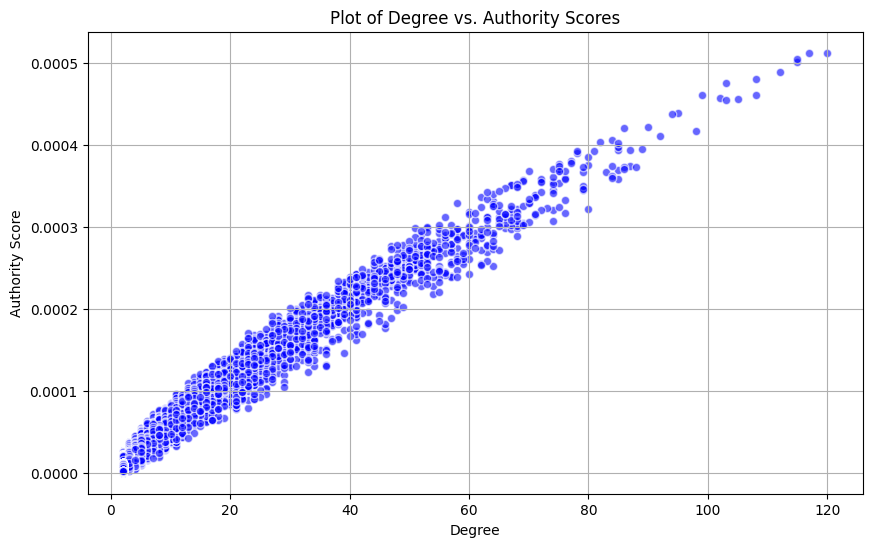

In [24]:
degrees = []
authority_scores = []

# Assuming auth_dict and degree_dict have the same keys
for node in auth_dict:
    degrees.append(degree_dict[node])
    authority_scores.append(auth_dict[node])

plt.figure(figsize=(10, 6))
plt.scatter(degrees, authority_scores, alpha=0.6, edgecolors='w', color='blue')
# plt.yscale('log')
# plt.xscale('log')
plt.title("Plot of Degree vs. Authority Scores")
plt.xlabel("Degree")
plt.ylabel("Authority Score")
plt.grid(True)
plt.show()


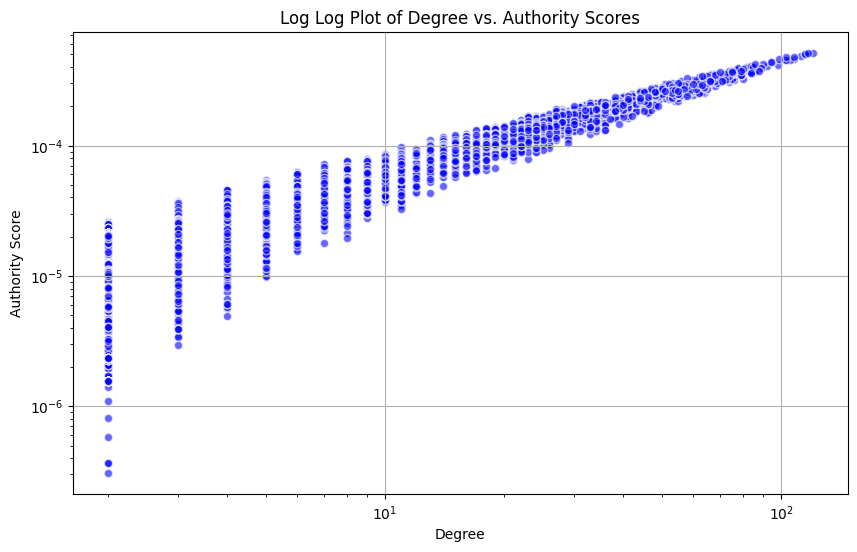

In [25]:
degrees = []
authority_scores = []

# Assuming auth_dict and degree_dict have the same keys
for node in auth_dict:
    degrees.append(degree_dict[node])
    authority_scores.append(auth_dict[node])

plt.figure(figsize=(10, 6))
plt.scatter(degrees, authority_scores, alpha=0.6, edgecolors='w', color='blue')
plt.yscale('log')
plt.xscale('log')
plt.title("Log Log Plot of Degree vs. Authority Scores")
plt.xlabel("Degree")
plt.ylabel("Authority Score")
plt.grid(True)
plt.show()


In [26]:
def calculate_metrics(alignment, community_label):
    """
    Calculate FFC, ARI, RI, and NMI from alignment data and graph nodes.

    Parameters:
        alignment (dict): Alignment data of communities to political parties.
        node_to_community (dict): Mapping of nodes to their assigned community.
        G (Graph): The graph with nodes and party information.

    Returns:
        dict: Calculated metrics.
    """
    # print(community_label[1])
    if community_label[1] == 'Republican':
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    # print(Republican, Democrat)
    # Extract counts
    true_positive_R = alignment[Republican]["R"]
    false_positive_R = alignment[Republican]["D"]
    true_positive_D = alignment[Democrat]["D"]
    false_positive_D = alignment[Democrat]["R"]
    # Precision and Recall for R
    precision_R = true_positive_R / (true_positive_R + false_positive_R) if (true_positive_R + false_positive_R) > 0 else 0
    recall_R = true_positive_R / (true_positive_R + false_positive_D) if (true_positive_R + false_positive_D) > 0 else 0
    
    # Precision and Recall for D
    precision_D = true_positive_D / (true_positive_D + false_positive_D) if (true_positive_D + false_positive_D) > 0 else 0
    recall_D = true_positive_D / (true_positive_D + false_positive_R) if (true_positive_D + false_positive_R) > 0 else 0

    # Macro Average (Optional)
    precision_macro = (precision_R + precision_D) / 2
    recall_macro = (recall_R + recall_D) / 2

    f1_score = 2*precision_macro*recall_macro/(precision_macro+recall_macro)  if (precision_macro+recall_macro) > 0 else 0
    accuracy = (true_positive_R+true_positive_D)/(true_positive_D+true_positive_R+false_positive_R+false_positive_D)


    return {
        "accuracy": accuracy,
        "f1": f1_score
    }


In [27]:
# def analyse_thresholds(df_data, authority_thresh=None, degree_thresh=None):
#     """
#     Analyze the effect of network metric thresholds on alignment metrics.

#     Parameters:
#         df_data (DataFrame): Data for the network.
#         follow_thresh_range (int): Maximum threshold value to analyze.
#         step (int): Step size for threshold increment.
#         metric_percentiles (list): List of percentiles to apply for each network metric threshold.

#     Returns:
#         None: Generates plots for various network metrics.
#     """
#     # metrics = ['authority', 'eigenvector', 'degree']
#     # metrics = ['authority', 'degree']
#     # results = {metric: {'accuracy': [], 'f1': [], 'modularity': []} for metric in metrics}
#     results = {}
#     results['no_metric'] = {'accuracy': [], 'f1': [], 'modularity': []}  # For the scenario without any metrics
#     thresholds = range(1, 21, 1)

#     # Precompute all centrality and authority metrics
#     G_directed = build_bipartite_network(df_data)
#     authority_scores, _ = calc_hits_values(G_directed, df_data)
#     # eigenvector_centrality, degree_centrality = calc_centrality_values(G_directed, df_data)
#     degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes() if node not in df_data['current_twitter_name'].values}


#     # Mapping metric names to their corresponding data
#     metric_data = {
#         'authority': authority_scores,
#         # 'eigenvector': eigenvector_centrality,
#         'degree': degree_centrality
#     }

#     for metric, scores in metric_data.items():
#         if metric == 'authority':
#             threshold_value = np.percentile(list(scores.values()), authority_thresh)
#             # threshold_value = authority_thresh
#         else:
#             # threshold_value = np.percentile(list(scores.values()), degree_thresh)
#             threshold_value = degree_thresh
#         print(metric, threshold_value)



#         """ CHECK THIS PROPERLY, I WAS REMOVING POLITICIANS COMPLETELY BEFORE BUT NOW AM KEEPING THEM IN IF THEY HAVE A HIGH ENOUGH AUTHORITY SCORE """


#         filtered_followees = {node for node, score in scores.items() if score >= threshold_value}
#         df_data['important_following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])
#         # Set of websites to exclude: those whose scores are below the threshold
#         # websites_to_exclude = {node for node, score in scores.items() if score < threshold_value}
#         # # print(len(websites_to_exclude), len(scores))

#         # # Update 'important_following' column
#         # df_data['important_following'] = df_data['following'].apply(
#         #     lambda followings: [f for f in followings if f not in websites_to_exclude]
#         # )

#         for follow_thresh in thresholds:
#             G = build_network(df_data, follow_thresh, True, True)  # Adjust true/false for hits as needed
#             _, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)
#             metrics = calculate_metrics(alignment, comm_labels)
            
#             results[metric]['accuracy'].append(metrics['accuracy'])
#             results[metric]['f1'].append(metrics['f1'])
#             results[metric]['modularity'].append(mod_value)

#     # Adding no metric scenario
#     for follow_thresh in thresholds:
#         G = build_network(df_data, follow_thresh, False, True)
#         _, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)
#         metrics = calculate_metrics(alignment, comm_labels)

#         results['no_metric']['accuracy'].append(metrics['accuracy'])
#         results['no_metric']['f1'].append(metrics['f1'])
#         results['no_metric']['modularity'].append(mod_value)

#     return thresholds, results


In [28]:
def analyse_thresholds(df_data, authority_thresh=None, degree_thresh=None):
    """
    Analyze the effect of network metric thresholds on alignment metrics using variable thresholds
    for different metrics.

    Parameters:
        df_data (DataFrame): Data for the network.
        authority_thresh (list of int): List of percentile values to apply as thresholds for authority scores.
        degree_thresh (list of int): List of percentile values to apply as thresholds for degree centrality.

    Returns:
        dict: A dictionary containing the results of the analysis with various metrics.
    """
    # Precompute all centrality and authority metrics
    G_directed = build_bipartite_network(df_data)
    authority_scores, _ = calc_hits_values(G_directed, df_data)
    degree_centrality = {node: G_directed.degree(node) for node in G_directed.nodes()}

    results = {'no_metric': {'accuracy': [], 'f1': [], 'modularity': []}}  # For the scenario without any metrics
    thresholds = range(1, 21, 1)

    # Mapping metric names to their corresponding thresholds
    metric_thresholds = {
        'authority': authority_thresh or [],
        'degree': degree_thresh or []
    }

    for metric, thresh_list in metric_thresholds.items():
        if not thresh_list:  # Skip metrics with empty threshold lists
            continue

        metric_scores = authority_scores if metric == 'authority' else degree_centrality
        for thresh in thresh_list:
            
            if metric == 'degree':
                threshold_value = thresh
                print(f"{metric} threshold at value {thresh}")
            else:
                threshold_value = np.percentile(list(metric_scores.values()), thresh)
                print(f"{metric} threshold at {thresh} percentile: {threshold_value}")
            
            

            # Filtering nodes based on threshold
            filtered_followees = {node for node, score in metric_scores.items() if score >= threshold_value}
            df_data['important_following'] = df_data['following'].apply(
                lambda followings: [f for f in followings if f in filtered_followees])

            # Initialize metric-specific results
            metric_key = f"{metric}_{thresh}"
            results[metric_key] = {'accuracy': [], 'f1': [], 'modularity': []}

            for follow_thresh in thresholds:
                G = build_network(df_data, follow_thresh, True, True)  # Assuming function signature exists
                # _, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)
                # metrics = calculate_metrics(alignment, comm_labels)
                communities, mod_value = apply_greedy_modularity_n_partitions(G, 2)
                alignment = political_alignment(G, communities)
                comm_labels = classify_communities(alignment)
                metrics = calculate_metrics(alignment, comm_labels)
                
                results[metric_key]['accuracy'].append(metrics['accuracy'])
                results[metric_key]['f1'].append(metrics['f1'])
                results[metric_key]['modularity'].append(mod_value)

    # Analyze without any metric
    for follow_thresh in thresholds:
        G = build_network(df_data, follow_thresh, False, True)
        communities, mod_value = apply_greedy_modularity_n_partitions(G, 2)
        alignment = political_alignment(G, communities)
        comm_labels = classify_communities(alignment)
        metrics = calculate_metrics(alignment, comm_labels)

        results['no_metric']['accuracy'].append(metrics['accuracy'])
        results['no_metric']['f1'].append(metrics['f1'])
        results['no_metric']['modularity'].append(mod_value)

    return thresholds, results


In [20]:
def plot_metrics(thresholds, results):
    """
    Function to plot accuracy, F1 score, and modularity metrics based on threshold experiments.
    Each metric's effect is shown in a separate graph for comparison, with special
    emphasis on the eigenvector centrality using markers.

    Parameters:
        thresholds (range): Range of thresholds used in experiments.
        results (dict): Results dictionary containing metrics data for each measurement.
    """

    # Plot for Accuracy
    plt.figure(figsize=(15, 7))
    for metric, data in results.items():
            # if metric == "degree":
            #     plt.plot(thresholds, data['accuracy'], label=f"{metric} Accuracy", marker='o', color='purple', linestyle='dotted')  # Add markers for eigenvector
            # else:
        plt.plot(thresholds, data['accuracy'], label=f"{metric} Accuracy")
    plt.title('Comparison of Accuracy Across Metrics')
    plt.xlabel('Threshold')
    plt.ylabel('Accuracy')
    plt.xticks(list(thresholds))
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot for F1 Score
    plt.figure(figsize=(15, 7))
    for metric, data in results.items():
        # if metric == "eigenvector":
        #     plt.plot(thresholds, data['f1'], label=f"{metric} F1 Score", marker='o', color='purple', linestyle='dotted')  # Add markers for eigenvector
        # else:
        plt.plot(thresholds, data['f1'], label=f"{metric} F1 Score")
    plt.title('Comparison of F1 Score Across Metrics')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.xticks(list(thresholds))
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot for Modularity
    plt.figure(figsize=(15, 7))
    for metric, data in results.items():
        if metric == "degree_2":
            plt.plot(thresholds, data['modularity'], label=f"{metric} Modularity", marker='o', color='purple', linestyle='dotted')  # Add markers for eigenvector
        else:
            plt.plot(thresholds, data['modularity'], label=f"{metric} Modularity")
    plt.title('Comparison of Modularity Across Metrics')
    plt.xlabel('Threshold')
    plt.ylabel('Modularity')
    plt.xticks(list(thresholds))
    plt.grid(True)
    plt.legend()
    plt.show()


In [30]:
thresholds, results = analyse_thresholds(df_data, None, [5,10,15])  # Example usage

degree threshold at value 5
degree threshold at value 10
degree threshold at value 15


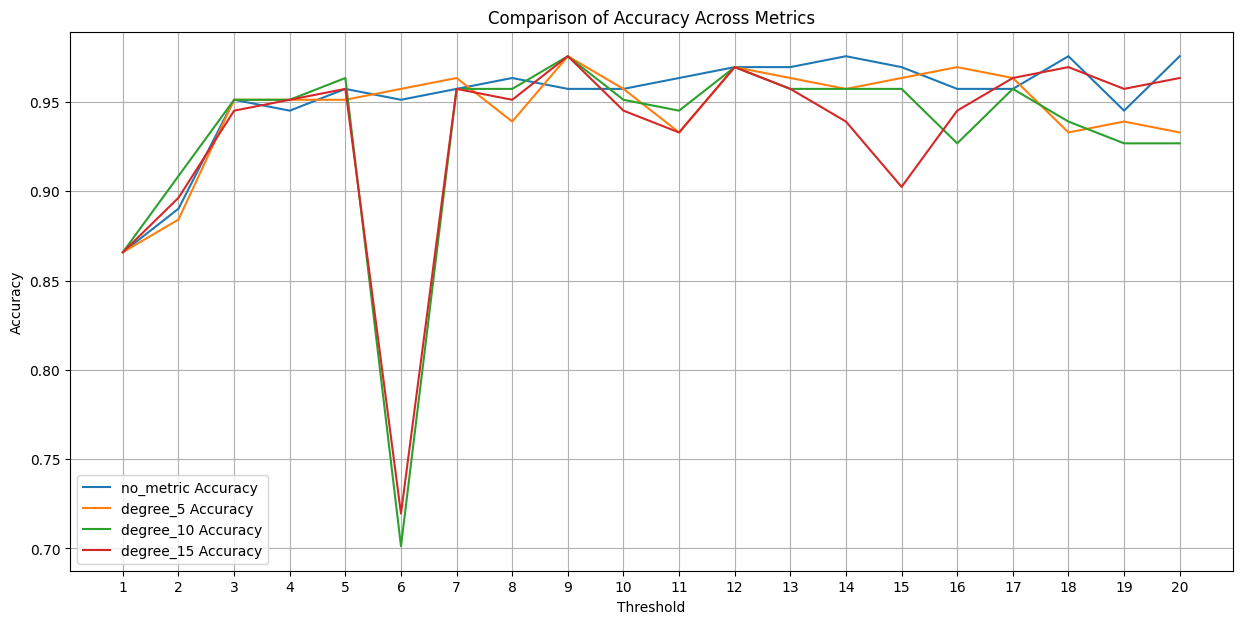

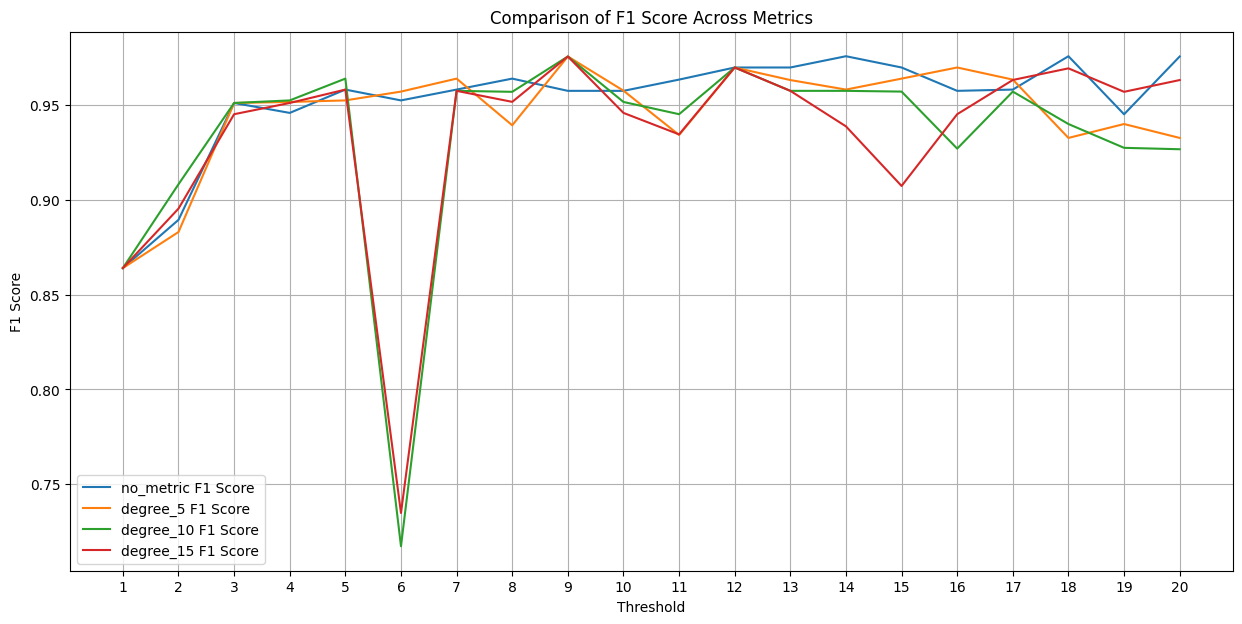

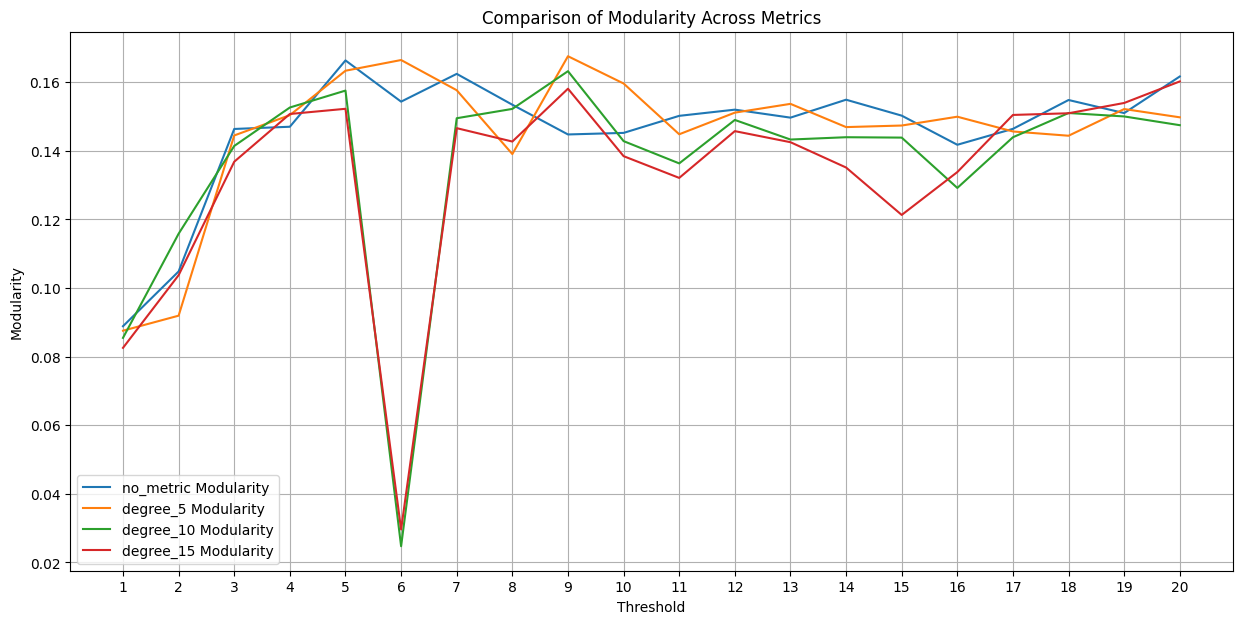

In [31]:
plot_metrics(thresholds, results)

In [95]:
G_directed = build_bipartite_network(df_data)
degree_centrality = {node: G_directed.degree(node) for node in G_directed.nodes()}

In [96]:
filtered_followees = {node for node, score in degree_centrality.items() if score >= 1}
print(len(filtered_followees))
filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
print(len(filtered_followees))


34364
34364


In [97]:
thresholds, results = analyse_thresholds(df_data, [75])

authority threshold at 75 percentile: 2.692050016225209e-05


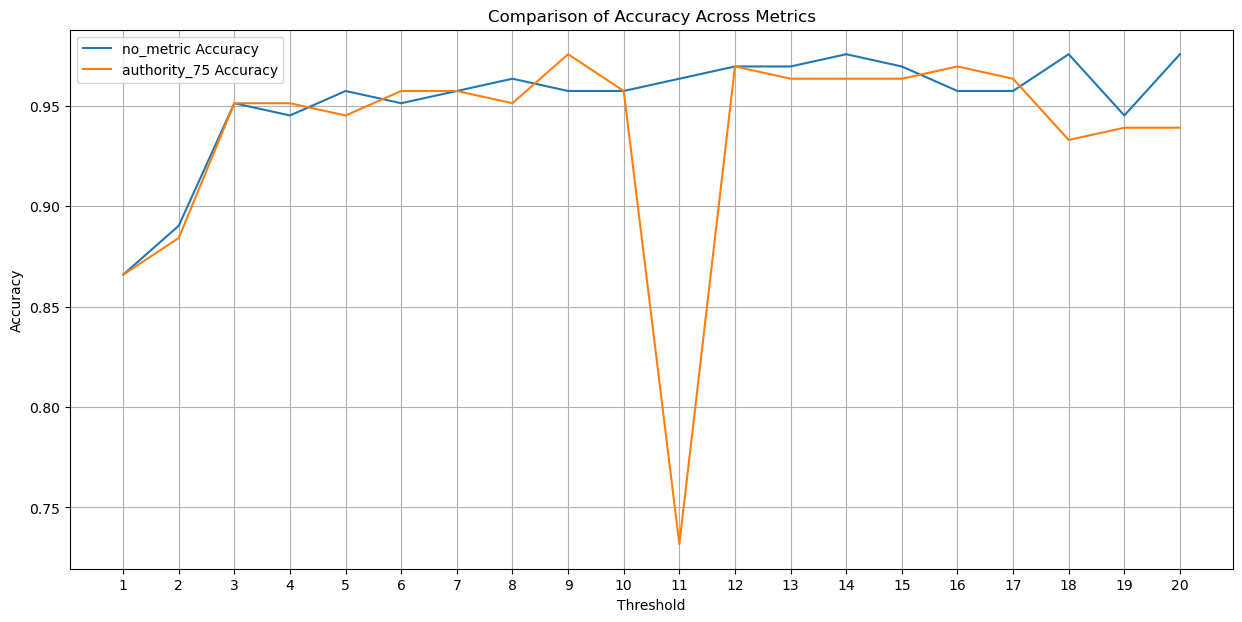

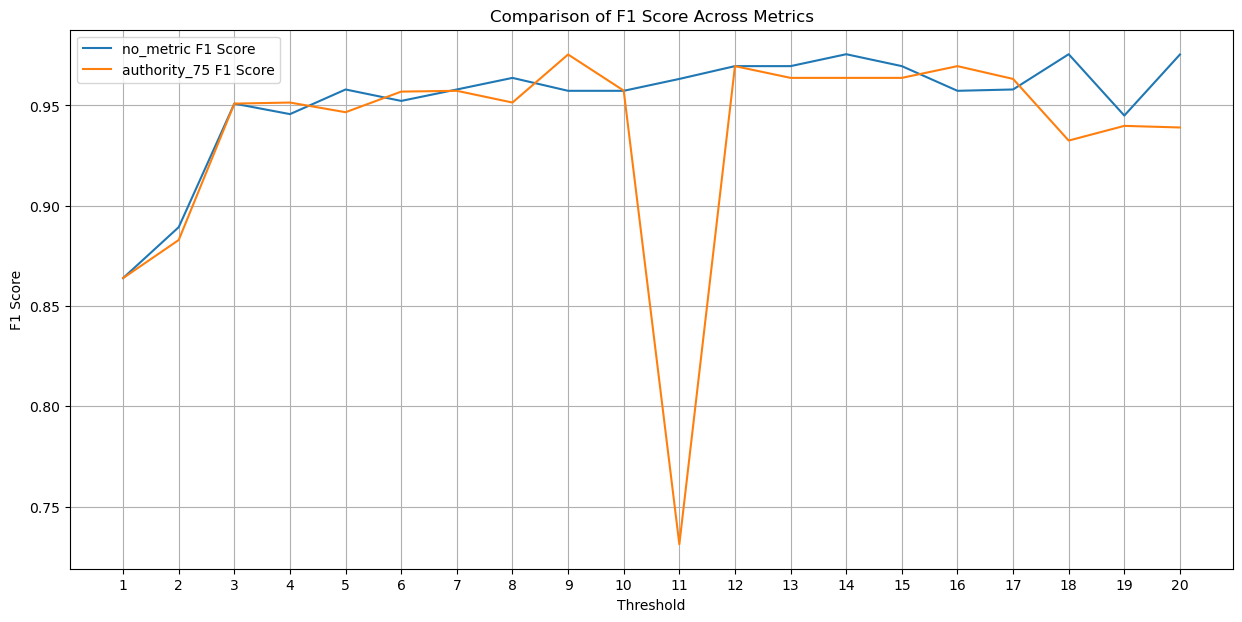

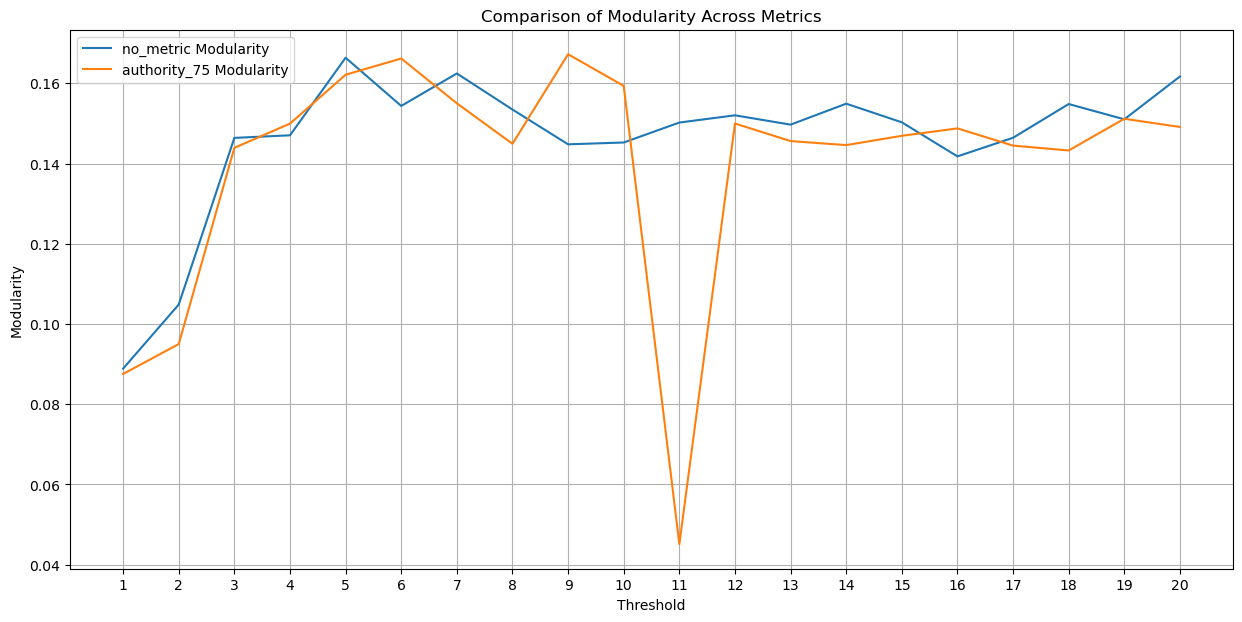

In [98]:
plot_metrics(thresholds, results)

In [21]:
def flatten(list_of_lists):
    """ Flatten a list of lists to a single list. """
    return [item for sublist in list_of_lists for item in sublist]


def evaluate_metrics(df_data, metric_percentiles):
    """
    Analyze the effect of network metric thresholds and percentile filters on alignment metrics.

    Parameters:
        df_data (DataFrame): Data for the network.
        threshold_value (int): The threshold value for filtering network connections.
        metric_percentiles (dict): Dictionary with metrics as keys and percentiles as values,
                                   specifying the filtering threshold for each metric.

    Returns:
        dict: Dictionary containing the results with accuracy, f1, and modularity for each scenario.
    """
    # metrics = ['authority', 'eigenvector', 'degree']
    # results = {metric: {'accuracy': [], 'f1': [], 'modularity': []} for metric in metrics}
    # results = {'accuracy': 0, 'f1': 0, 'modularity': 0}  # For the scenario without any metrics
    results = {}
    results['with_metric'] = {'accuracy': [], 'f1': [], 'modularity': []}
    results['no_metric'] = {'accuracy': [], 'f1': [], 'modularity': []}  # For the scenario without any metrics
    thresholds = range(1,21,1)
    # Assume these functions are defined elsewhere in your codebase
    G_directed = build_bipartite_network(df_data)
    authority_scores, _ = calc_hits_values(G_directed, df_data)
    # eigenvector_centrality, degree_centrality = calc_centrality_values(G_directed, df_data)
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}

    # Mapping metric names to their corresponding data
    metric_data = {
        'authority': authority_scores,
        # 'eigenvector': eigenvector_centrality,
        'degree': degree_centrality
    }

    important_followees = set(flatten(df_data['following'].tolist()))  # Initialize with all followees
    for metric, scores in metric_data.items():
        if metric_percentiles[metric] == 0:
            filtered_followees = set(scores.keys())
        else:
            percentile_threshold = np.percentile(list(scores.values()), metric_percentiles[metric])
            filtered_followees = {node for node, score in scores.items() if score >= percentile_threshold}
        important_followees.intersection_update(filtered_followees)  # Apply combined filtering

    df_data['important_following'] = df_data['following'].apply(
        lambda followings: [f for f in followings if f in important_followees]
    )

    for follow_thresh in thresholds:
        # Analyze network with the specific threshold
        G = build_network(df_data, follow_thresh, True, True)  # Adjust this as necessary
        try:
            _, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)
            a_f1_metrics = calculate_metrics(alignment, comm_labels)

        except:
            a_f1_metrics = {}
            a_f1_metrics['accuracy'] = 0
            a_f1_metrics['f1'] = 0
            mod_value = 0

        # Store results for the specified threshold and metrics
        results['with_metric']['accuracy'].append(a_f1_metrics['accuracy'])
        results['with_metric']['f1'].append(a_f1_metrics['f1'])
        results['with_metric']['modularity'].append(mod_value)

    # Adding no metric scenario
    for follow_thresh in thresholds:
        G = build_network(df_data, follow_thresh, False, True)
        _, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)
        metrics = calculate_metrics(alignment, comm_labels)

        results['no_metric']['accuracy'].append(metrics['accuracy'])
        results['no_metric']['f1'].append(metrics['f1'])
        results['no_metric']['modularity'].append(mod_value)

    return thresholds, results


In [ ]:
metric_percentiles = {'authority': 11, 'degree':89}
thresholds, results = evaluate_metrics(df_data, metric_percentiles)

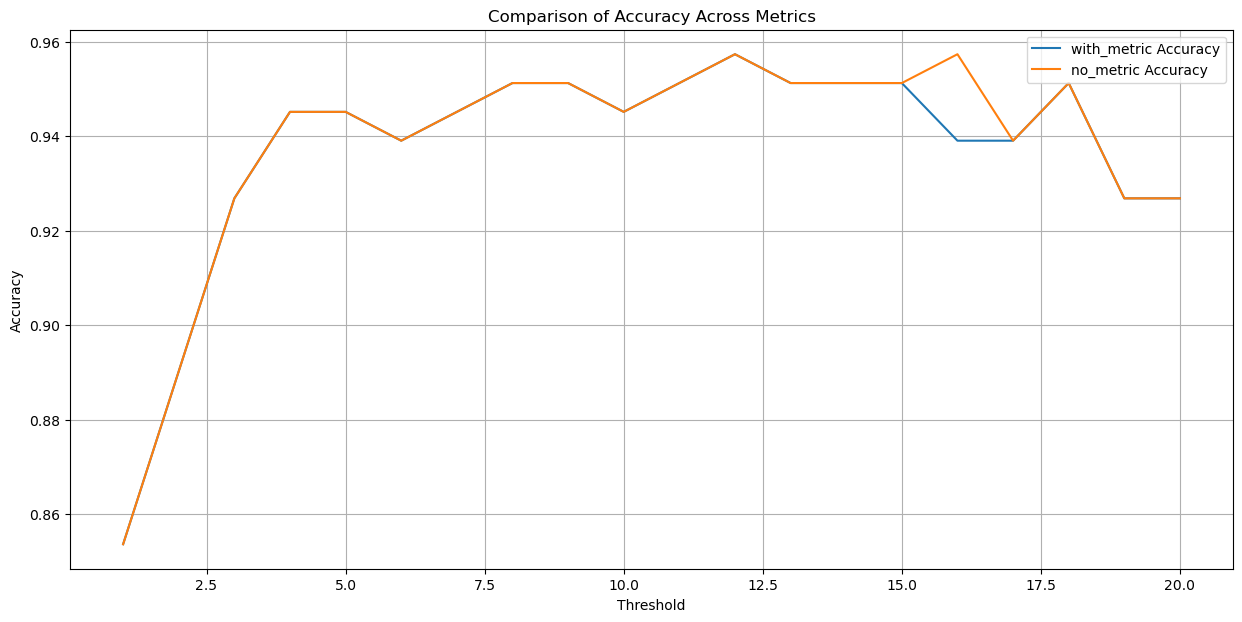

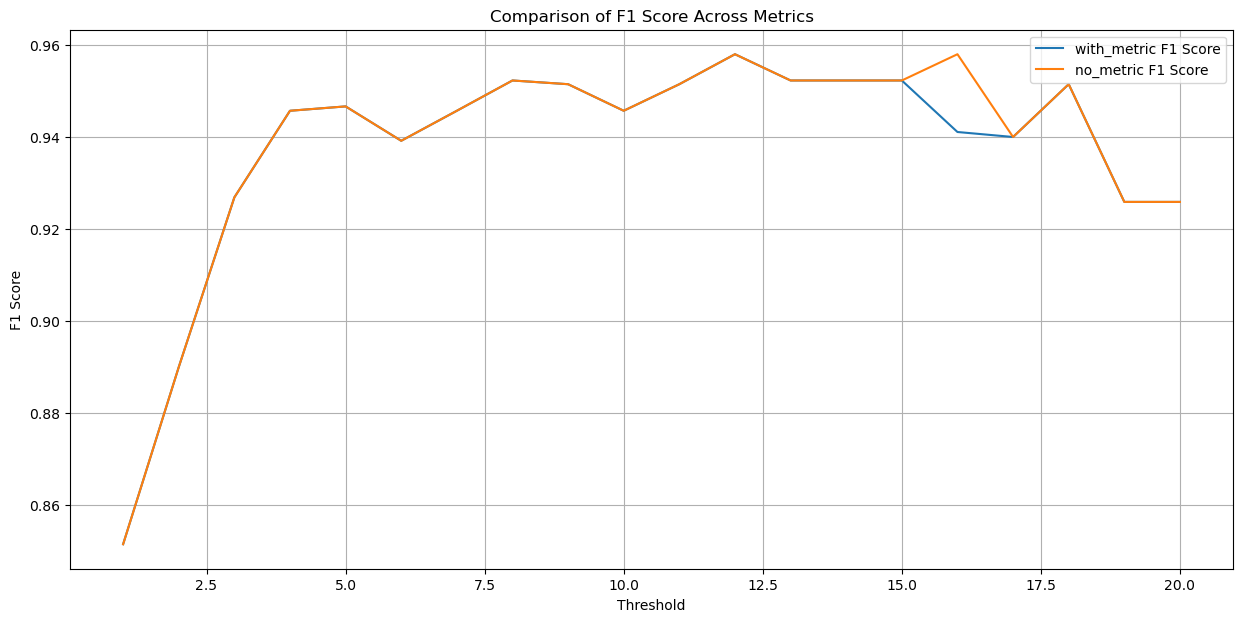

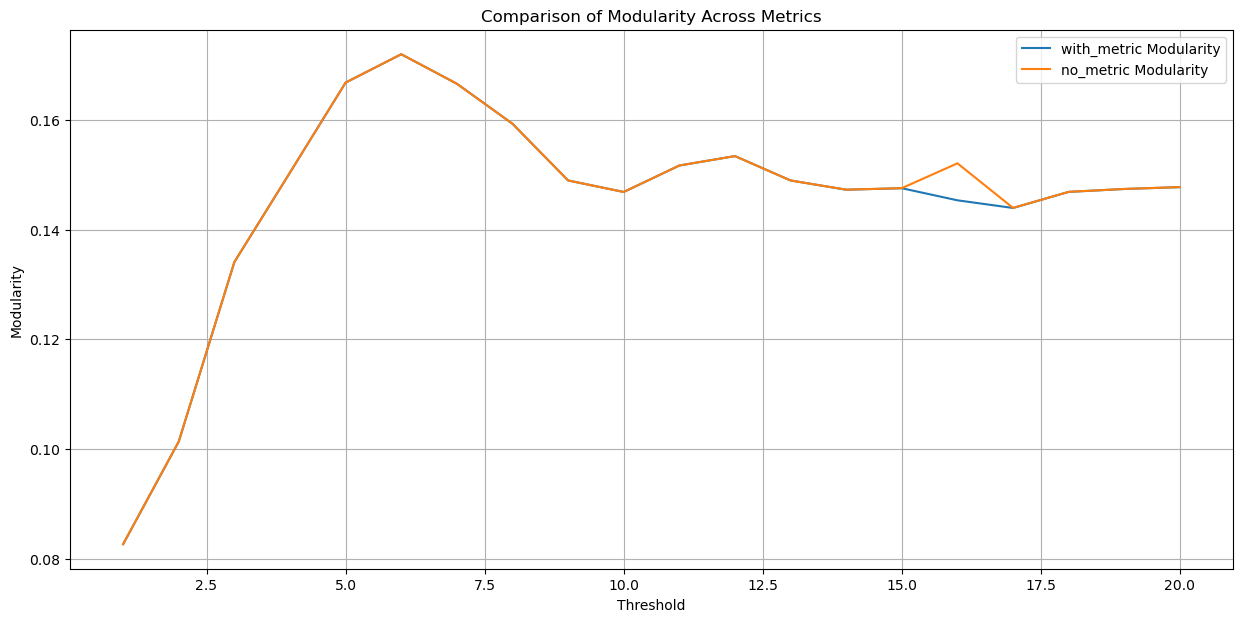

In [ ]:
plot_metrics(thresholds, results)

In [ ]:
def network_analysis_and_plot(df_data, threshold_value, metric_percentiles):
    """
    Analyze the network based on given threshold and metric percentiles, printing details about
    the number of nodes considered unimportant, the degree distribution, and total edges.

    Parameters:
        df_data (DataFrame): Data for the network.
        threshold_value (int): Threshold for building the network.
        metric_percentiles (dict): Dictionary with metrics as keys and percentiles as values.
    """
    G_directed = build_bipartite_network(df_data)
    authority_scores, _ = calc_hits_values(G_directed, df_data)
    # eigenvector_centrality, degree_centrality = calc_centrality_values(G_directed, df_data)
    degree_centrality = {node: G_directed.degree(node) for node in G_directed.nodes()}

    # Metric data preparation
    metric_data = {
        'authority': authority_scores,
        # 'eigenvector': eigenvector_centrality,
        'degree': degree_centrality
    }

    # Filter followees based on metrics
    # all_followees = set(flatten(df_data['following'].tolist()))
    all_followees = set(degree_centrality.keys())
    important_followees = set(all_followees)
    for metric, scores in metric_data.items():
        # percentile_threshold = np.percentile(list(scores.values()), metric_percentiles[metric])
        # filtered_followees = {node for node, score in scores.items() if score >= percentile_threshold}
        # important_followees.intersection_update(filtered_followees)
        if metric_percentiles[metric] == 0:
            filtered_followees = set(scores.keys())
            print(len(filtered_followees))
        else:
            percentile_threshold = np.percentile(list(scores.values()), metric_percentiles[metric])
            print(f"{metric} percentile threshold ({metric_percentiles[metric]}%):", percentile_threshold)
            filtered_followees = {node for node, score in scores.items() if score >= percentile_threshold}
        important_followees.intersection_update(filtered_followees)

    # Filtered followees count
    unimportant_followees = all_followees - important_followees
    df_data['important_following'] = df_data['following'].apply(
        lambda followings: [f for f in followings if f in important_followees]
    )

    # Build network with specified threshold
    G = build_network(df_data, threshold_value, True, True)
    try:
        _, alignment, mod_value, comm_labels = apply_greedy_modularity_two_partitions(G)
        a_f1_metrics = calculate_metrics(alignment, comm_labels)

    except:
        a_f1_metrics = {}
        a_f1_metrics['accuracy'] = 0
        a_f1_metrics['f1'] = 0
        mod_value = 0
    results = {}
    results['accuracy'] = a_f1_metrics['accuracy']
    results['f1'] = a_f1_metrics['f1']
    results['modularity'] = mod_value
    # Extract network properties
    number_of_nodes = G.number_of_nodes()
    number_of_edges = G.number_of_edges()
    degree_distribution = dict(G.degree())
    degree_values = sorted(degree_distribution.values())
    degree_counts = {deg: sum(1 for v in degree_distribution.values() if v == deg) for deg in set(degree_values)}

    # Print the results
    print("Results:", results)
    print("Total websites before removal:", len(all_followees))
    print("Number of unimportant websites:", len(unimportant_followees))
    print("Number of important websites:", len(important_followees))
    print("Total number of edges:", number_of_edges)
    print("Total number of nodes:", number_of_nodes)
    print("Degree Distribution:", degree_counts)
    total_score = 0
    for key, value in degree_counts.items():
        total_score += key * value
        
    avg_degree = total_score / number_of_nodes
    print("Avg degree dist of whole network:", avg_degree)

    # Plotting the degree distribution
    plt.figure(figsize=(10, 5))
    plt.bar(degree_counts.keys(), degree_counts.values(), color='b')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Distribution of the Whole Network')
    plt.grid(True)
    plt.show()
    
    


authority percentile threshold (21%): 9.655619760997691e-06
degree percentile threshold (79%): 5.0
Results: {'accuracy': 0, 'f1': 0, 'modularity': 0}
Total websites before removal: 34364
Number of unimportant websites: 26502
Number of important websites: 7862
Total number of edges: 9847
Total number of nodes: 164
Degree Distribution: {0: 5, 1: 1, 128: 1, 129: 1, 4: 1, 130: 1, 131: 2, 132: 3, 133: 2, 9: 1, 10: 1, 11: 1, 134: 2, 135: 1, 136: 1, 137: 8, 138: 2, 17: 1, 139: 3, 140: 5, 141: 3, 21: 1, 142: 9, 143: 6, 144: 5, 145: 13, 146: 9, 147: 7, 28: 1, 29: 1, 149: 9, 150: 2, 152: 1, 33: 1, 155: 2, 40: 1, 62: 1, 68: 1, 74: 1, 76: 1, 80: 1, 82: 2, 83: 1, 84: 1, 85: 1, 90: 1, 93: 1, 94: 2, 98: 2, 100: 1, 148: 6, 106: 1, 108: 1, 109: 1, 110: 1, 112: 1, 113: 2, 115: 2, 116: 1, 117: 1, 120: 1, 121: 1, 122: 3, 123: 2, 124: 5, 125: 2, 127: 2}
avg degree dist: 120.08536585365853


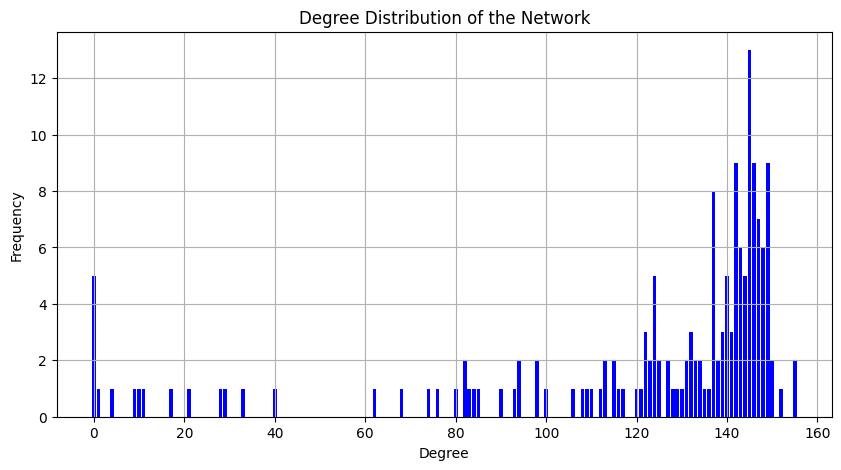

In [23]:
metric_percentiles = {'authority': 21, 'degree':79}

network_analysis_and_plot(df_data, 20, metric_percentiles)

In [2]:
metric_percentiles = {'authority': 0, 'eigenvector':0, 'degree':0}

network_analysis_and_plot(df_data, 5, metric_percentiles)

NameError: name 'df_data' is not defined

In [ ]:
metric_percentiles = {'authority': 88, 'eigenvector':91, 'degree':58}

network_analysis_and_plot(df_data, 26, metric_percentiles)

authority percentile threshold (88%): 9.656001323598924e-06
eigenvector percentile threshold (91%): 0.0021237983934983646
degree percentile threshold (58%): 6.093065482174737e-06
Total websites before removal: 163958
Number of unimportant websites: 155299
Number of important websites: 8659
Total number of edges: 9287
Total number of nodes: 164
Degree Distribution: {0: 8, 1: 1, 2: 1, 128: 3, 4: 1, 129: 2, 130: 4, 7: 1, 131: 3, 132: 4, 133: 4, 11: 1, 134: 1, 135: 1, 136: 4, 137: 3, 138: 8, 17: 1, 18: 1, 139: 7, 140: 7, 141: 3, 142: 9, 23: 1, 143: 9, 144: 7, 145: 4, 146: 3, 147: 1, 148: 4, 149: 2, 150: 1, 41: 1, 50: 1, 54: 1, 61: 1, 62: 1, 66: 1, 70: 1, 73: 1, 75: 1, 76: 1, 77: 1, 79: 3, 80: 1, 82: 2, 92: 1, 97: 2, 98: 1, 101: 1, 105: 2, 106: 2, 108: 2, 109: 1, 111: 2, 113: 2, 114: 2, 115: 2, 117: 5, 118: 1, 120: 2, 121: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 4}


In [ ]:
metric_percentiles = {'authority': 0, 'eigenvector':0, 'degree':0}

network_analysis_and_plot(df_data, 26, metric_percentiles)

163958
163958
163958
Total websites before removal: 163958
Number of unimportant websites: 0
Number of important websites: 163958
Total number of edges: 9363
Total number of nodes: 164
Degree Distribution: {0: 2, 1: 2, 2: 4, 128: 2, 129: 3, 5: 2, 130: 6, 131: 2, 132: 3, 9: 1, 10: 1, 133: 5, 134: 3, 13: 1, 135: 1, 136: 1, 137: 5, 138: 4, 18: 1, 139: 10, 140: 3, 141: 8, 22: 1, 142: 6, 24: 1, 144: 9, 145: 5, 146: 5, 147: 1, 148: 3, 149: 3, 150: 1, 152: 1, 42: 1, 51: 1, 55: 1, 63: 1, 64: 1, 67: 1, 72: 1, 74: 1, 76: 1, 77: 1, 79: 1, 80: 2, 81: 1, 82: 2, 83: 1, 143: 7, 95: 1, 97: 1, 99: 1, 100: 1, 102: 1, 105: 1, 107: 2, 108: 1, 109: 2, 111: 2, 112: 1, 113: 1, 114: 2, 115: 3, 117: 1, 118: 3, 119: 1, 120: 1, 122: 1, 123: 3, 125: 1, 126: 1, 127: 2}


In [ ]:
metric_percentiles = {'authority': 1, 'eigenvector':9, 'degree':72}

network_analysis_and_plot(df_data, 50, metric_percentiles)

authority percentile threshold (1%): 3.916590283405505e-07
eigenvector percentile threshold (9%): 2.7646898326241632e-09
degree percentile threshold (72%): 6.093065482174737e-06
Total websites before removal: 163958
Number of unimportant websites: 1620
Number of important websites: 162338
Total number of edges: 7704
Total number of nodes: 164
Degree Distribution: {0: 9, 1: 5, 2: 3, 11: 1, 13: 1, 15: 1, 18: 1, 19: 1, 33: 1, 34: 1, 44: 1, 50: 3, 52: 1, 53: 1, 54: 1, 55: 1, 56: 2, 57: 1, 60: 2, 62: 1, 66: 1, 70: 1, 73: 2, 74: 1, 75: 2, 76: 2, 77: 1, 78: 2, 79: 2, 80: 1, 83: 2, 85: 1, 86: 1, 91: 1, 93: 1, 94: 1, 95: 1, 96: 1, 98: 1, 100: 3, 101: 1, 103: 2, 104: 1, 106: 1, 107: 1, 109: 2, 110: 2, 112: 2, 113: 3, 114: 3, 115: 3, 116: 1, 117: 1, 118: 3, 119: 4, 120: 3, 121: 5, 122: 5, 123: 4, 124: 1, 125: 2, 126: 6, 127: 3, 128: 3, 129: 9, 130: 6, 131: 2, 132: 4, 133: 1, 134: 1, 135: 2, 136: 2, 137: 1, 139: 1, 142: 2, 143: 1, 144: 1, 146: 3}


In [ ]:
metric_percentiles = {'authority': 0, 'eigenvector':0, 'degree':0}

network_analysis_and_plot(df_data, 50, metric_percentiles)

163958
163958
163958
Total websites before removal: 163958
Number of unimportant websites: 0
Number of important websites: 163958
Total number of edges: 7704
Total number of nodes: 164
Degree Distribution: {0: 9, 1: 5, 2: 3, 11: 1, 13: 1, 15: 1, 18: 1, 19: 1, 33: 1, 34: 1, 44: 1, 50: 3, 52: 1, 53: 1, 54: 1, 55: 1, 56: 2, 57: 1, 60: 2, 62: 1, 66: 1, 70: 1, 73: 2, 74: 1, 75: 2, 76: 2, 77: 1, 78: 2, 79: 2, 80: 1, 83: 2, 85: 1, 86: 1, 91: 1, 93: 1, 94: 1, 95: 1, 96: 1, 98: 1, 100: 3, 101: 1, 103: 2, 104: 1, 106: 1, 107: 1, 109: 2, 110: 2, 112: 2, 113: 3, 114: 3, 115: 3, 116: 1, 117: 1, 118: 3, 119: 4, 120: 3, 121: 5, 122: 5, 123: 4, 124: 1, 125: 2, 126: 6, 127: 3, 128: 3, 129: 9, 130: 6, 131: 2, 132: 4, 133: 1, 134: 1, 135: 2, 136: 2, 137: 1, 139: 1, 142: 2, 143: 1, 144: 1, 146: 3}


In [ ]:
metric_percentiles = {'authority': 28, 'eigenvector':14, 'degree':68}

network_analysis_and_plot(df_data, 48, metric_percentiles)

authority percentile threshold (28%): 2.4591154703697916e-06
eigenvector percentile threshold (14%): 2.7646898326241632e-09
degree percentile threshold (68%): 6.093065482174737e-06
Total websites before removal: 163958
Number of unimportant websites: 45379
Number of important websites: 118579
Total number of edges: 7818
Total number of nodes: 164
Degree Distribution: {0: 9, 1: 4, 2: 4, 128: 3, 129: 6, 130: 9, 131: 4, 132: 2, 133: 4, 134: 1, 135: 1, 136: 2, 137: 1, 13: 1, 14: 1, 138: 2, 140: 1, 143: 3, 145: 1, 19: 2, 146: 2, 147: 1, 22: 1, 34: 1, 37: 1, 48: 1, 50: 1, 51: 1, 53: 2, 54: 1, 55: 1, 56: 1, 58: 1, 59: 2, 60: 1, 61: 1, 64: 1, 70: 1, 73: 1, 75: 2, 78: 5, 79: 2, 81: 2, 83: 2, 84: 1, 86: 2, 87: 1, 95: 3, 97: 1, 99: 1, 100: 1, 103: 3, 104: 1, 105: 1, 106: 2, 107: 1, 108: 1, 110: 1, 111: 1, 112: 2, 113: 2, 114: 1, 115: 1, 116: 6, 117: 1, 119: 2, 120: 7, 121: 3, 122: 3, 123: 6, 124: 2, 125: 3, 126: 5, 127: 3}


In [ ]:
metric_percentiles = {'authority': 0, 'eigenvector':0, 'degree':0}

network_analysis_and_plot(df_data, 48, metric_percentiles)

163958
163958
163958
Total websites before removal: 163958
Number of unimportant websites: 0
Number of important websites: 163958
Total number of edges: 7824
Total number of nodes: 164
Degree Distribution: {0: 8, 1: 4, 2: 5, 128: 2, 129: 7, 130: 9, 131: 4, 132: 2, 133: 4, 134: 1, 135: 1, 136: 2, 137: 1, 13: 1, 14: 1, 138: 2, 140: 1, 143: 3, 145: 1, 19: 1, 20: 1, 146: 2, 22: 1, 147: 1, 34: 1, 37: 1, 48: 1, 51: 1, 52: 1, 53: 1, 54: 2, 55: 1, 56: 1, 58: 1, 59: 2, 60: 1, 61: 1, 64: 1, 70: 1, 73: 1, 75: 2, 78: 5, 79: 1, 80: 1, 81: 2, 83: 2, 84: 1, 86: 2, 87: 1, 95: 2, 96: 1, 97: 1, 100: 2, 103: 3, 104: 1, 105: 1, 106: 1, 107: 2, 109: 1, 110: 1, 111: 1, 112: 2, 113: 2, 114: 1, 115: 1, 116: 6, 117: 1, 119: 2, 120: 7, 121: 3, 122: 3, 123: 6, 124: 2, 125: 3, 126: 5, 127: 3}
